# Reporting Notebook (Final)

This notebook assembles the final reporting outputs for the project:
- the selected clustering solution (KMeans, k=4, Variant B),
- cluster summary table,
- cluster-average temporal profiles,
- Milan grid cluster map,
- key limitations and interpretation notes.

All final figures/tables are saved to `results/final/`.

# Imports, Output dir, save helper

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FINAL_DIR = Path("../results/final")
FINAL_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name: str):
    out = FINAL_DIR / f"{name}.png"
    plt.savefig(out, dpi=250, bbox_inches="tight")
    print("Saved figure:", out.resolve())

# Load model from pathlib import Path

In [4]:
import json
import joblib

MODELS_DIR = Path("../models")

card_path = MODELS_DIR / "model_card_k4.json"
assign_path = MODELS_DIR / "cluster_assignments_k4.parquet"
model_path = MODELS_DIR / "kmeans_k4_variantB.joblib"

raw_feat_path = Path("../results/preprocessing/features_hourly_weekday_weekend_mean_FULL.parquet")

model_card = json.loads(card_path.read_text())
assign = pd.read_parquet(assign_path)
X_raw_feat = pd.read_parquet(raw_feat_path).sort_values("square_id").reset_index(drop=True)

kmeans = joblib.load(model_path)

print("Loaded model card:", card_path)
print("Loaded assignments:", assign_path, "| shape:", assign.shape)
print("Loaded raw feature table:", raw_feat_path, "| shape:", X_raw_feat.shape)

Loaded model card: ..\models\model_card_k4.json
Loaded assignments: ..\models\cluster_assignments_k4.parquet | shape: (10000, 3)
Loaded raw feature table: ..\results\preprocessing\features_hourly_weekday_weekend_mean_FULL.parquet | shape: (10000, 241)


# Final cluster summary table

In [5]:
channels = ["sms_in", "sms_out", "call_in", "call_out", "internet_traffic"]
hours = list(range(24))

def cols_for(regime, channel):
    return [f"{regime}_hour_{h:02d}_{channel}_mean" for h in hours]

df_lbl = X_raw_feat.merge(assign[["square_id", "cluster_k4", "cluster_label"]], on="square_id", how="left")
df_lbl = df_lbl.rename(columns={"cluster_k4": "cluster"})

weekday_total = df_lbl[[c for ch in channels for c in cols_for("weekday", ch)]].sum(axis=1)
weekend_total = df_lbl[[c for ch in channels for c in cols_for("weekend", ch)]].sum(axis=1)

day_hours = list(range(7, 20))
night_hours = [h for h in hours if h not in day_hours]

weekday_day = df_lbl[[f"weekday_hour_{h:02d}_internet_traffic_mean" for h in day_hours]].sum(axis=1)
weekday_night = df_lbl[[f"weekday_hour_{h:02d}_internet_traffic_mean" for h in night_hours]].sum(axis=1)

df_lbl["weekday_total_all_channels"] = weekday_total
df_lbl["weekend_total_all_channels"] = weekend_total
df_lbl["weekend_weekday_ratio"] = (weekend_total + 1e-9) / (weekday_total + 1e-9)
df_lbl["weekday_day_night_ratio_internet"] = (weekday_day + 1e-9) / (weekday_night + 1e-9)

summary = (
    df_lbl.groupby(["cluster", "cluster_label"])
    .agg(
        n_squares=("square_id", "count"),
        share=("square_id", lambda s: len(s) / df_lbl.shape[0]),
        weekday_total=("weekday_total_all_channels", "mean"),
        weekend_total=("weekend_total_all_channels", "mean"),
        weekend_weekday_ratio=("weekend_weekday_ratio", "mean"),
        day_night_ratio_internet=("weekday_day_night_ratio_internet", "mean"),
    )
    .reset_index()
    .sort_values("weekday_total", ascending=False)
)

display(summary)

summary_path = FINAL_DIR / "cluster_summary_k4.csv"
summary.to_csv(summary_path, index=False)
print("Saved summary table:", summary_path.resolve())

,cluster,cluster_label,n_squares,share,weekday_total,weekend_total,weekend_weekday_ratio,day_night_ratio_internet
3,3,High-activity core,861,0.0861,9974.131581,7723.087559,0.804898,2.188926
1,1,Urban mixed-use,2101,0.2101,2677.780788,2283.440801,0.873904,2.082472
2,2,Moderate activity,3561,0.3561,1095.808139,932.225891,0.861446,2.115055
0,0,Low activity / peripheral,3477,0.3477,305.543623,257.207036,0.857038,2.090361


Saved summary table: C:\Users\Lu\OneDrive\ToU\chl_Clustering\results\final\cluster_summary_k4.csv


# Cluster profile visualizations (two levels of detail)

To communicate what the clusters *mean* in practice, I will visualize the **cluster-average hourly profiles** for the selected solution (KMeans, k=4).

I will do this in two ways:

1) **Primary view (single-channel): Internet traffic**  
Internet traffic typically provides a strong, smooth signal of urban activity intensity and daily rhythms. This is the cleanest “first story” to explain the cluster structure.

2) **Robustness view (multi-channel): Internet traffic + call_out + sms_out**  
To verify that clusters are not an artifact of a single variable, I will also show profiles for outgoing calls and outgoing SMS. Consistency across channels increases confidence that the clusters reflect meaningful behavioral patterns rather than noise.

After generating these plots, I will interpret the key differences between clusters in terms of weekday vs weekend rhythms and plausible urban zone functions.

## Generate profile plots

Next I generate:
- Internet traffic profiles (weekday and weekend), then
- Multi-channel profiles (internet_traffic, call_out, sms_out) for weekday and weekend.

All figures are saved to `results/final/` for use in the final report.

Saved figure: C:\Users\Lu\OneDrive\ToU\chl_Clustering\results\final\report_profile_k4_internet_traffic_weekday.png


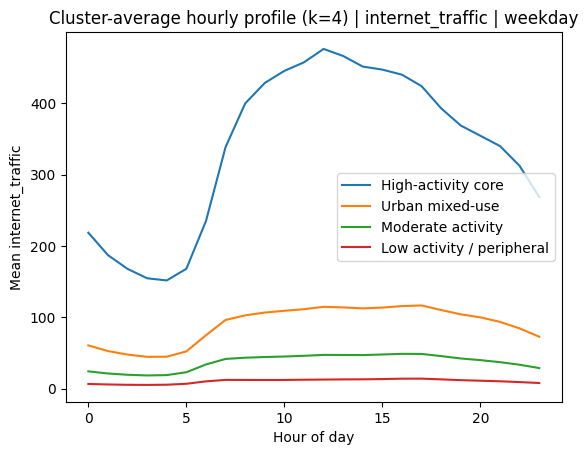

Saved figure: C:\Users\Lu\OneDrive\ToU\chl_Clustering\results\final\report_profile_k4_internet_traffic_weekend.png


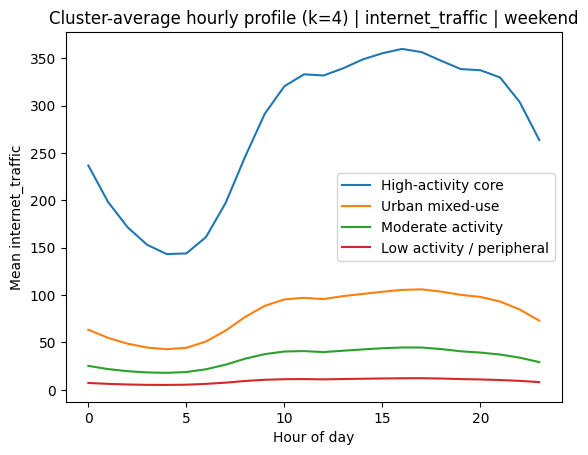

In [6]:
channels_to_plot = ["internet_traffic"]
k = 4

def plot_profiles_reporting(df_lbl, cluster_order, channel):
    for reg in ["weekday", "weekend"]:
        plt.figure()
        for cl in cluster_order:
            sub = df_lbl[df_lbl["cluster"] == cl]
            cols = [f"{reg}_hour_{h:02d}_{channel}_mean" for h in range(24)]
            prof = sub[cols].mean().values
            label = sub["cluster_label"].iloc[0]
            plt.plot(range(24), prof, label=label)

        plt.title(f"Cluster-average hourly profile (k={k}) | {channel} | {reg}")
        plt.xlabel("Hour of day")
        plt.ylabel(f"Mean {channel}")
        plt.legend()
        save_fig(f"report_profile_k{k}_{channel}_{reg}")
        plt.show()

# Use cluster order by weekday_total descending (from summary table)
cluster_order = summary.sort_values("weekday_total", ascending=False)["cluster"].tolist()
plot_profiles_reporting(df_lbl, cluster_order, "internet_traffic")

Saved figure: C:\Users\Lu\OneDrive\ToU\chl_Clustering\results\final\report_profile_k4_internet_traffic_weekday.png


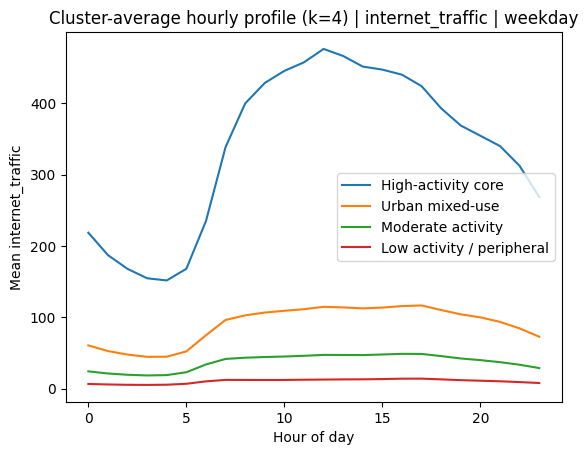

Saved figure: C:\Users\Lu\OneDrive\ToU\chl_Clustering\results\final\report_profile_k4_internet_traffic_weekend.png


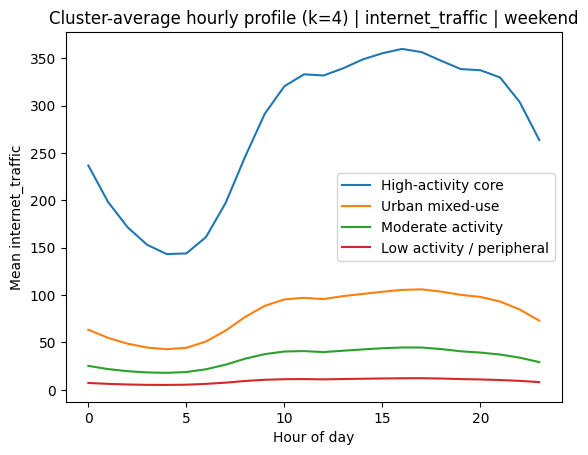

Saved figure: C:\Users\Lu\OneDrive\ToU\chl_Clustering\results\final\report_profile_k4_call_out_weekday.png


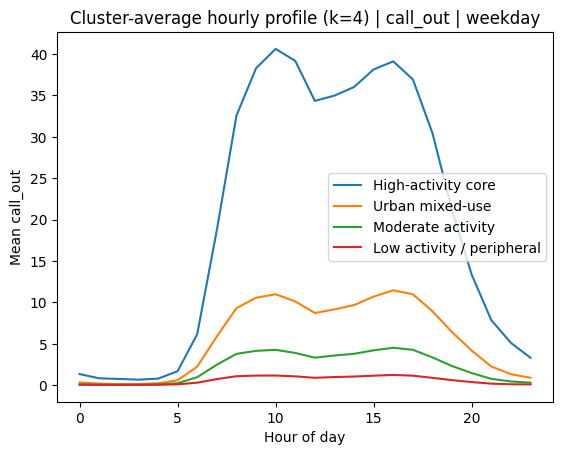

Saved figure: C:\Users\Lu\OneDrive\ToU\chl_Clustering\results\final\report_profile_k4_call_out_weekend.png


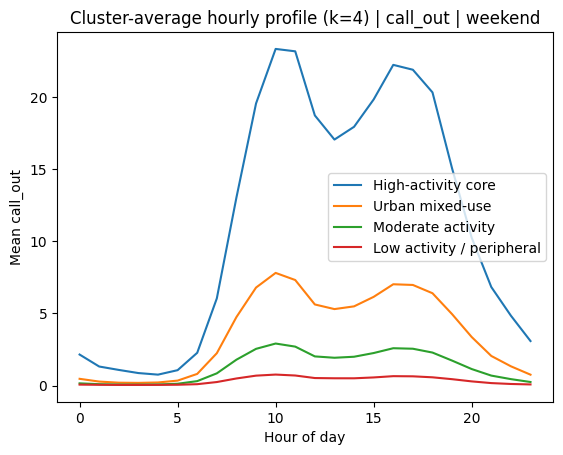

Saved figure: C:\Users\Lu\OneDrive\ToU\chl_Clustering\results\final\report_profile_k4_sms_out_weekday.png


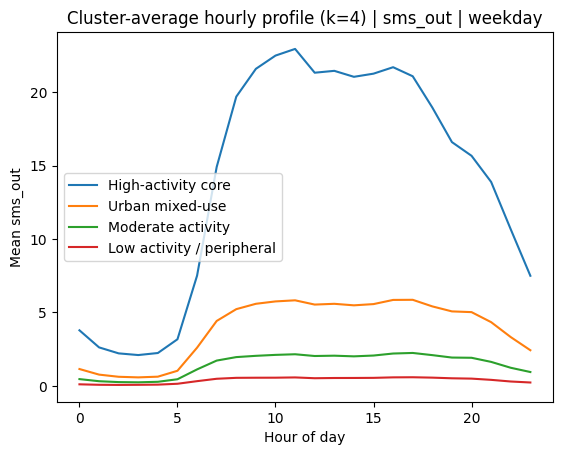

Saved figure: C:\Users\Lu\OneDrive\ToU\chl_Clustering\results\final\report_profile_k4_sms_out_weekend.png


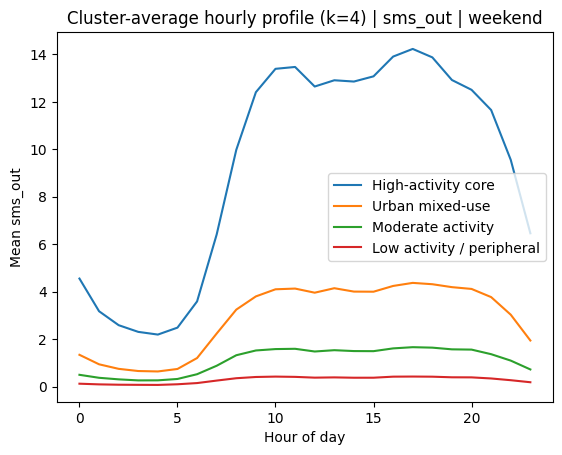

In [7]:
channels_to_plot = ["internet_traffic", "call_out", "sms_out"]
k = 4

cluster_order = summary.sort_values("weekday_total", ascending=False)["cluster"].tolist()

for ch in channels_to_plot:
    plot_profiles_reporting(df_lbl, cluster_order, ch)

## Interpretation of cluster-average temporal profiles (k=4)

Across all three channels (internet traffic, outgoing calls, outgoing SMS), the cluster ordering is consistent: **High-activity core > Urban mixed-use > Moderate activity > Low activity/peripheral**. This consistency across channels increases confidence that the clusters reflect genuine differences in urban activity intensity and rhythms rather than artifacts of a single variable.

### 1) Internet traffic (primary signal)
- **High-activity core** shows the strongest and clearest diurnal cycle: a low point in the early morning, a sharp rise starting around **06:00–08:00**, and a broad **daytime plateau** through the afternoon, followed by a gradual decline into the evening.  
  → This pattern is consistent with highly central, employment- and service-dense areas (high daytime presence and activity).
- **Urban mixed-use** follows the same shape but at a substantially lower level, suggesting areas that are active throughout the day but less intense than the core.  
  → Plausible as inner-city mixed residential/commercial neighborhoods.
- **Moderate activity** and **Low activity/peripheral** are progressively flatter and lower magnitude, with weaker daytime lift.  
  → Plausible as more residential/peripheral zones with lower overall intensity.

**Weekday vs weekend:** weekend curves preserve the same rank ordering, but the high-activity core’s daytime level is reduced relative to weekday, consistent with a weekday-oriented “work” component in the core.

### 2) Outgoing calls (behavioral rhythm check)
Outgoing calls show a more “peaky” structure than internet traffic:
- **High-activity core** shows a strong rise in the morning and a pronounced daytime pattern (with visible midday/afternoon structure), then a decline in the evening.
- Lower-intensity clusters follow the same timing but at much smaller magnitudes.

**Weekday vs weekend:** overall call volumes drop on weekends, but the timing structure remains similar, suggesting stable daily rhythms across the city with intensity differentiating zones.

### 3) Outgoing SMS (secondary consistency check)
SMS patterns are broadly consistent with calls:
- the **high-activity core** again dominates in magnitude,
- mixed-use and moderate clusters show scaled-down versions of the same daily cycle,
- the peripheral cluster remains low and relatively flat.

**Weekday vs weekend:** weekend volumes are lower but preserve ordering and general shape, reinforcing that clusters differentiate zones in a stable way across behavioral regimes.

### Overall takeaway
For k=4, clusters primarily separate the city into **four intensity-based functional zone types** with consistent weekday/weekend rhythm structure. The “core vs inner ring vs outer ring” interpretation is supported both by:
- consistent temporal ordering across multiple activity channels, and
- stable daily cycle timing (morning ramp-up and daytime concentration) that aligns with known urban dynamics.

On the Map, it looks like this:

Saved figure: C:\Users\Lu\OneDrive\ToU\chl_Clustering\results\final\report_gridmap_k4.png


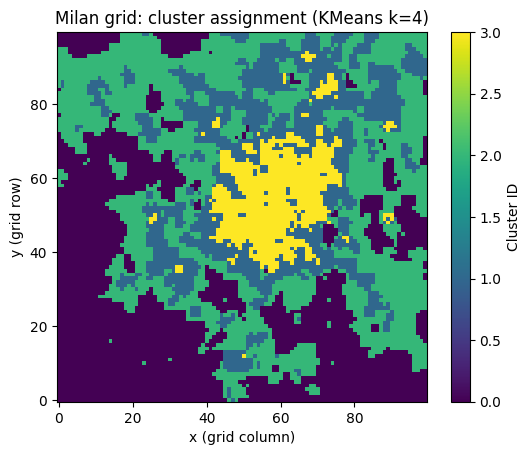

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Use assignments with cluster labels already loaded as `assign`
# Columns expected: square_id, cluster_k4, cluster_label
assign_sorted = assign.sort_values("square_id").reset_index(drop=True)

square_ids = assign_sorted["square_id"].values
labels = assign_sorted["cluster_k4"].values  # numeric labels 0..3

n_cols = 100
grid = np.full((100, 100), fill_value=-1, dtype=int)

# square_id -> (x,y) mapping (your Scheme A)
x = ((square_ids - 1) % n_cols) + 1
y = ((square_ids - 1) // n_cols) + 1

for xi, yi, lab in zip(x, y, labels):
    grid[yi - 1, xi - 1] = lab

plt.figure()
im = plt.imshow(grid, origin="lower")
plt.title("Milan grid: cluster assignment (KMeans k=4)")
plt.xlabel("x (grid column)")
plt.ylabel("y (grid row)")

cbar = plt.colorbar(im)
cbar.set_label("Cluster ID")

save_fig("report_gridmap_k4")
plt.show()

Comparing it to the Google Maps map, we can clearly see the correlations between our clusters and regions on the map (e.g. Airport, greenland, inner city)

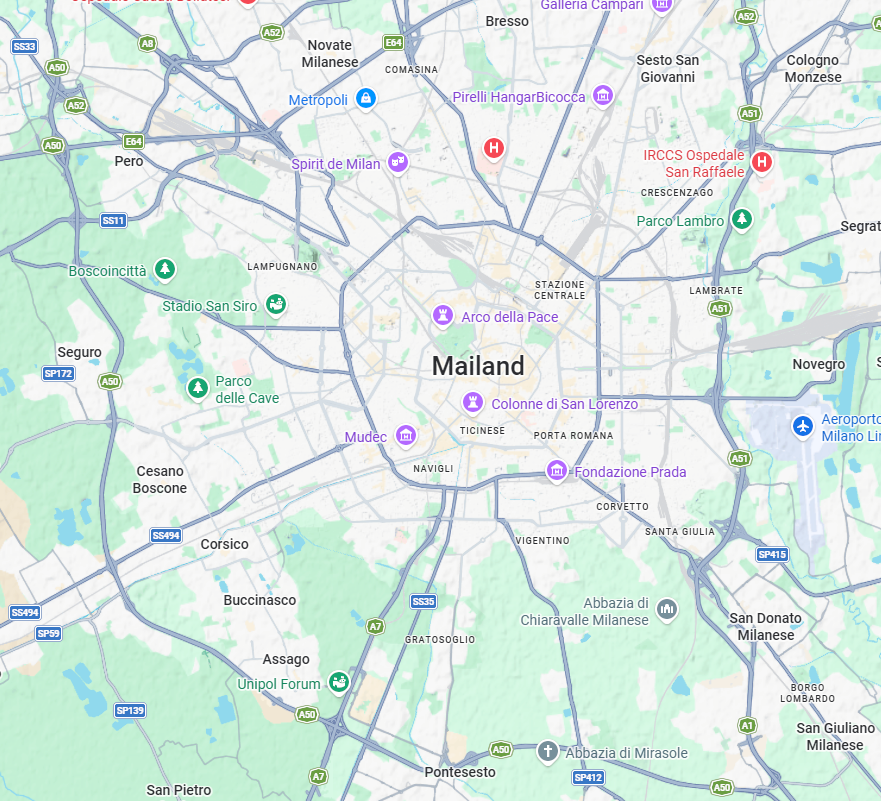

## Results Summary (Final Model)

### Selected clustering solution
- **Algorithm:** KMeans  
- **Chosen k:** 4  
- **Preprocessing:** **Variant B** (log1p transform + StandardScaler)  
- **Feature representation:** 240 features per grid cell = (weekday/weekend) × (24 hourly bins) × (5 activity channels)

This configuration was selected because it produced **stable clusters** during train/holdout checks and yielded **highly interpretable temporal profiles** and **spatially plausible** cluster maps.

### Cluster typology (k=4)
Using the cluster profiling table and the cluster-average temporal curves, the four clusters can be summarized as:

- **Cluster 3 — High-activity core (≈ 8.6%)**  
  Highest intensity across all channels, strong weekday daytime plateau and clear morning ramp-up. Spatially concentrated in the center of the grid, consistent with a dense urban core.

- **Cluster 1 — Urban mixed-use (≈ 21.0%)**  
  Second-highest activity with similar daily shape but lower magnitude, consistent with inner-city mixed residential/commercial areas surrounding the core.

- **Cluster 2 — Moderate activity (≈ 35.6%)**  
  Moderate intensity and smoother rhythms, plausibly representing more residential or less central urban fabric.

- **Cluster 0 — Low activity / peripheral (≈ 34.8%)**  
  Lowest intensity across channels with relatively flat profiles, plausibly representing peripheral, low-density, or less active zones.

### Key empirical patterns
- **Consistency across channels:** Internet traffic, outgoing calls, and outgoing SMS all preserve the same cluster ordering and show coherent daily rhythms, supporting that clusters reflect meaningful differences rather than noise.
- **Weekday vs weekend regime:** Weekend activity is generally lower than weekdays while preserving the same cluster rank ordering, suggesting stable functional zone differences with predictable regime shifts.
- **Spatial plausibility:** The Milan grid map shows non-random spatial structure (clear core + surrounding zones), indicating that cluster assignments align with geographic patterns rather than fragmenting into noise.

### Limitations and interpretation cautions
- Telecom activity is a **proxy** for urban dynamics; it does not directly measure trips, land use, demographics, or service access.
- The dataset covers **late 2013–early 2014**, so results should be framed as methodological/illustrative unless validated with more recent data.
- Clusters should be interpreted as **functional activity profiles**, not as labels of social value or need; conclusions should remain non-stigmatizing and context-aware.